In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import seaborn as sns
sns.set_style("darkgrid")

### Load the dataset from the file Ecommerce.csv

```
This dataset includes the following data for 200 online customers:

- Email
- Adress
- Avatar
- Avg Session Length (everage time they spent on usage)
- Time on App (time they spent using the application)
- Time on Website (time they spent using the website)
- Length of Membership (for how long they have been a user)
- Yearly Amount Spent (how much money they spend yearly)

Yout goal will be to estimate the value of the Yearly Amount Spent using the feature(s) of the users
```

In [6]:
df = pd.read_csv('../data/Ecommerce.csv')

In [8]:
df.head()

,Email,Address,Avatar,Avg Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [10]:
df.shape

(500, 8)

In [13]:
df.describe()

,Avg Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

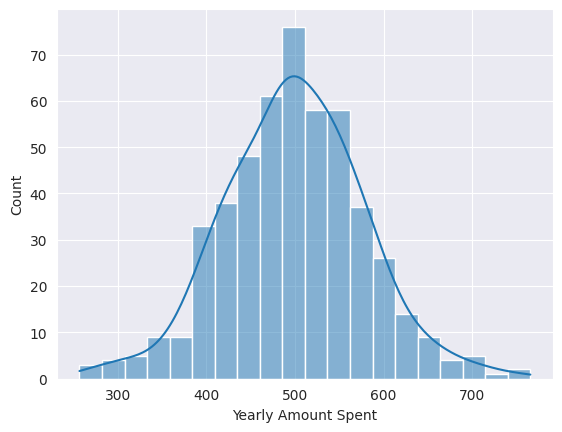

In [17]:
sns.histplot(df['Yearly Amount Spent'], kde=True)

In [20]:
corr_matric = df.corr(numeric_only=True)

### Get rid of non-numerical columns of the dataset

In [22]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()

,Avg Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


### Use Yearly Amount Spent as your target variable. Plot the relationship of each of the numerical features with the target variable

In [29]:
y = df['Yearly Amount Spent']
X = df.drop(columns=['Yearly Amount Spent'])

X

,Email,Address,Avatar,Avg Session Length,Time on App,Time on Website,Length of Membership
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,33.000915,11.330278,37.110597,4.104543
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308
...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872Lake Jamiefurt, U...",Tan,33.237660,13.566160,36.417985,3.746573
496,katrina56@gmail.com,"172 Owen Divide Suite 497West Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633South Chadburgh, TN...",Cornsilk,32.646777,11.499409,38.332576,4.958264
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808Brendachester, TX 0...",Teal,33.322501,12.391423,36.840086,2.336485


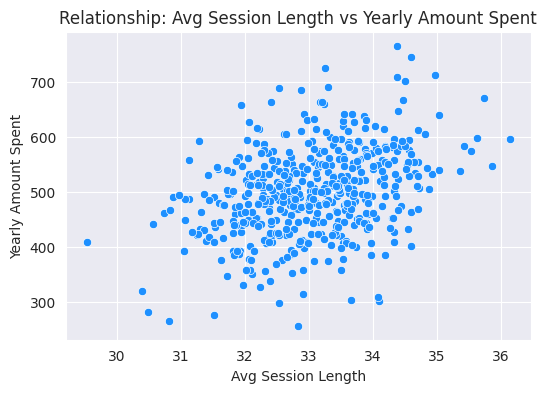

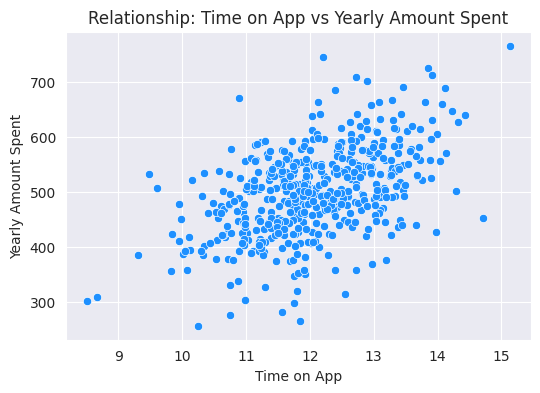

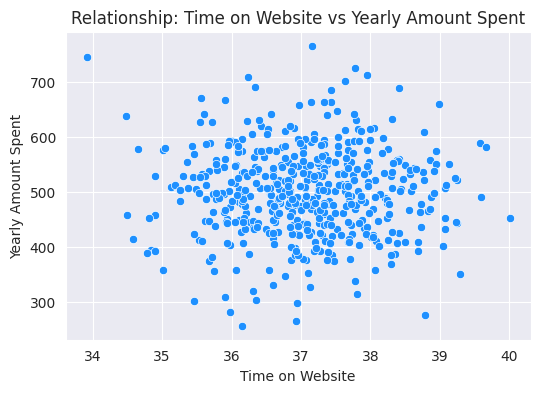

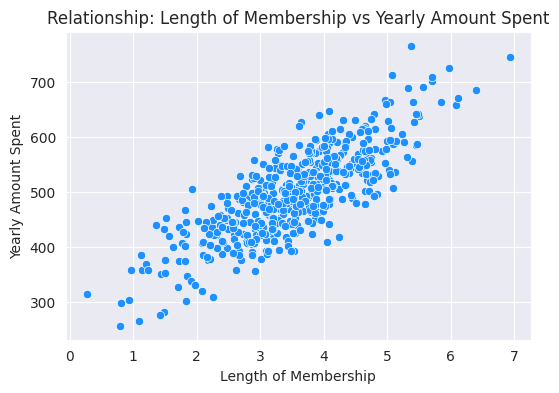

In [31]:
numerical_features = ['Avg Session Length', 'Time on App', 'Time on Website', 'Length of Membership']

for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='Yearly Amount Spent', color='dodgerblue')
    plt.title(f'Relationship: {col} vs Yearly Amount Spent')
    plt.xlabel(col)
    plt.ylabel('Yearly Amount Spent')
    plt.show()

### Leave only one feature that has a linear relationship with the target variable.

In [62]:
X = df[['Length of Membership']]

### Divide the dataset into training and test sets with the ratio 80:20.

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
model = LinearRegression()

### Use the resulting train and test sets with the next 2 functions to fit linear regression and plot the resulting regression line.

The first function is `fit_1d_linear_regression` that takes two vectors $x$ and $y$, and returns a numpy array ($\beta_0, \beta_1)$, where $\beta_0$ is the intercept of the line, and $\beta_1$ is the slope. 

In [64]:
def fit_1d_linear_regression(data_vector, response_vector):
    """
    :param data_vector: A pandas series object (i.e. a column of a dataframe),
                        where each element is a data point (x)
    :param response_vector: A pandas series object (i.e. a column of a dataframe),
                        where each element is label (y)
    :return: numpy array beta of coefficients of the regression
    Note: You can avoid the intercept for simplicity
    """    

    x_mean = data_vector.mean()
    y_mean = response_vector.mean()

    numerator = np.sum((data_vector - x_mean) * (response_vector - y_mean))
    denom = np.sum((data_vector - x_mean)**2)

    b1 = numerator / denom
    b0 = y_mean - b1*x_mean

    return np.array([b0, b1])

The second function is `plot_line` function, that takes $\beta_0, \beta_1, x, y$ and plots a scatter plot of the data, and the line $y = \beta_0 + \beta_1 x$. And saves the plot in `YOURNAME.png`

In [67]:
def plot_fitted_line(b0: float,
                     b1: float,
                     x,
                     y,
                     username: str):
    """
    :param b0: Intersept of line to plot
    Note: avoid this if you don't have an intercept in the previous function
    :param b1: Slope of the line to plot
    :param x: A pandas series object (i.e. a column of a dataframe),
                        where each element is a data point (x coordinates)
    :param y: A pandas series object (i.e. a column of a dataframe),
                        where each element is a label (y coordinates)
    """
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y)
    plt.plot(x, b0 + b1*x, color='orange', linewidth=3, label=f"{b0:.2f} + {b1:.2f}x")
    plt.xlabel(x.name)
    plt.ylabel(y.name)
    plt.title("Regression line "+x.name+" vs "+y.name)
    plt.legend()
    
    #plt.savefig(f'{username}.png', bbox_inches='tight')

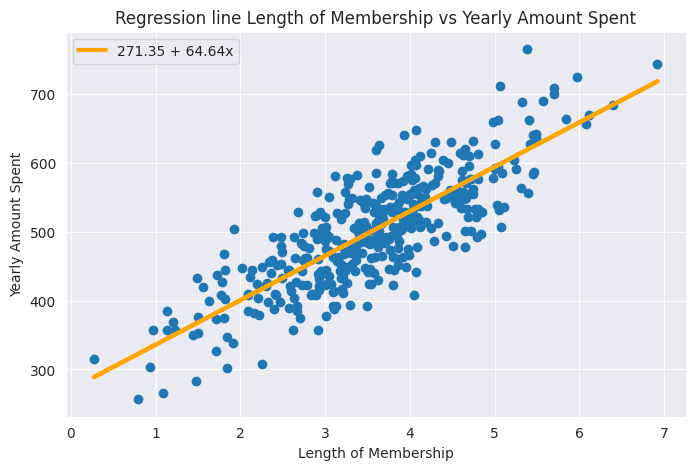

In [71]:
coeffs = fit_1d_linear_regression(X_train['Length of Membership'], y_train)
plot_fitted_line(coeffs[0], coeffs[1], X_train['Length of Membership'], y_train, 'ML_Advanced')

### Now fit the linear regression to the data containing only 1 feature using sklearn and compare the results with your own fit_1d_linear_regression function

In [84]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [88]:
model.coef_, model.intercept_

(array([64.64010065]), np.float64(271.3521128033932))

In [89]:
print(f"Sklearn Intercept (b0): {model.intercept_:.4f} | my Intercept: {coeffs[0]:.4f}")
print(f"Sklearn Slope (b1):     {model.coef_[0]:.4f} | my Slope:     {coeffs[1]:.4f}")

Sklearn Intercept (b0): 271.3521 | my Intercept: 271.3521
Sklearn Slope (b1):     64.6401 | my Slope:     64.6401


### Use sklearn.metrics to calculate Mean absolute error, Mean squared error, Root mean squared error and R-squared for the results of your own function vs the sklearn regression results. Try to interprete your results.

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

my_y_pred = coeffs[0] + coeffs[1]*X_test["Length of Membership"]

mae_sk = mean_absolute_error(y_test, y_pred)
mse_sk = mean_squared_error(y_test, y_pred)
rmse_sk = np.sqrt(mse_sk)
r2_sk = r2_score(y_test, y_pred)

mae_my = mean_absolute_error(y_test, my_y_pred)
mse_my = mean_squared_error(y_test, my_y_pred)
rmse_my = np.sqrt(mse_my)
r2_my = r2_score(y_test, my_y_pred)

print(f"mae: sk: {mae_sk} vs my: {mae_my}")
print(f"mse: sk: {mse_sk} vs my: {mse_my}")
print(f"rmse: sk: {rmse_sk} vs my: {rmse_my}")
print(f"r2: sk: {r2_sk} vs my: {r2_my}")



mae: sk: 37.836233900332424 vs my: 37.83623390033242
mse: sk: 2162.1116327764244 vs my: 2162.1116327764244
rmse: sk: 46.49851215658867 vs my: 46.49851215658867
r2: sk: 0.5633624502240147 vs my: 0.5633624502240147


### Fit linear regression to the data containing all numerical features using sklearn and use the same metrics to evaluate how good the model is.

In [113]:
X = numeric_df.drop(columns='Yearly Amount Spent')
y = numeric_df['Yearly Amount Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model.coef_

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"mse: {mse}, mae: {mae}, rmse: {rmse}, r2: {r2}")

mse: 109.86374118394066, mae: 8.558441885315247, rmse: 10.481590584636507, r2: 0.9778130629184125


/tmp/ipykernel_41027/2713152956.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='blue')


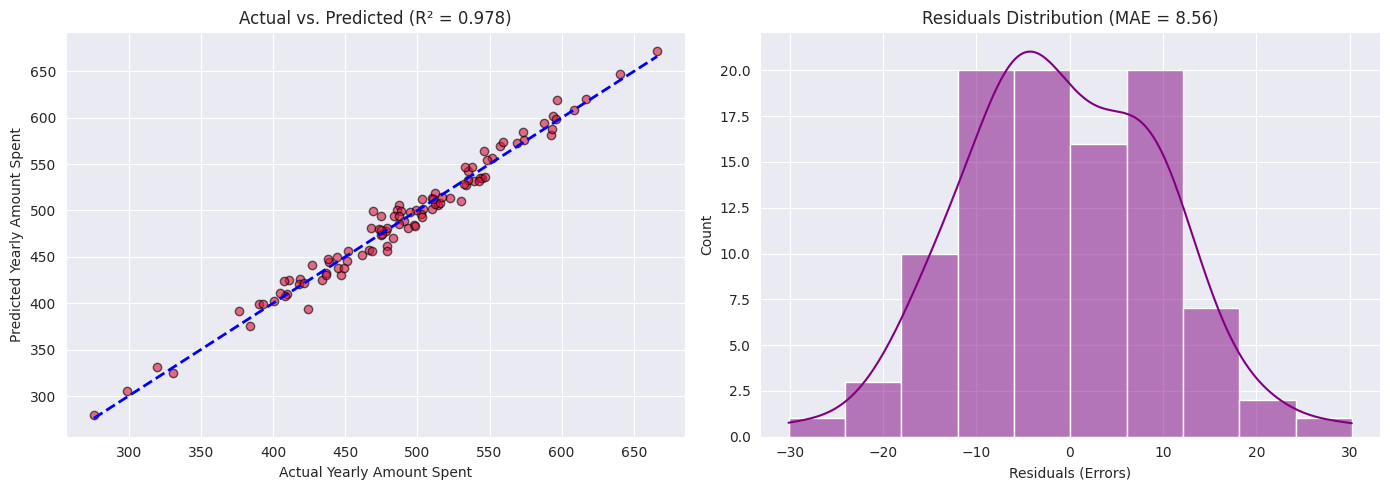

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(y_test, y_pred, alpha=0.6, color='crimson', edgecolors='k')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='blue')
ax[0].set_xlabel('Actual Yearly Amount Spent')
ax[0].set_ylabel('Predicted Yearly Amount Spent')
ax[0].set_title(f'Actual vs. Predicted (R² = {r2:.3f})')

residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=ax[1], color='purple')
ax[1].set_xlabel('Residuals (Errors)')
ax[1].set_title(f'Residuals Distribution (MAE = {mae:.2f})')

plt.tight_layout()
plt.show()

### Implement K-fold Cross Validation (optional)

In [124]:
scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train_fold, y_train_fold)
    
    predictions = model.predict(X_test_fold)
    
    rmse_fold = np.sqrt(mean_squared_error(y_test_fold, predictions))
    scores.append(rmse_fold)
    
    print(f"Fold {fold + 1} RMSE: {rmse_fold:.4f}")

print(f"\nAverage 10-Fold CV RMSE: {np.mean(scores):.4f}")

Fold 1 RMSE: 9.1675
Fold 2 RMSE: 11.6221
Fold 3 RMSE: 9.7054
Fold 4 RMSE: 9.1742
Fold 5 RMSE: 9.6672
Fold 6 RMSE: 10.8112
Fold 7 RMSE: 10.6532
Fold 8 RMSE: 9.1820
Fold 9 RMSE: 10.0903
Fold 10 RMSE: 9.4414

Average 10-Fold CV RMSE: 9.9515


### Evaluate model with K-fold